In [55]:
import pandas as pd
import numpy as np
from modAL.models import ActiveLearner
from modAL.uncertainty import entropy_sampling, margin_sampling, uncertainty_sampling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from tensorflow import keras
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Activation, AveragePooling2D, Conv2DTranspose, ZeroPadding2D
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten, Conv1D, BatchNormalization
from sklearn.metrics import mean_squared_error

from matplotlib import pyplot as plt
import seaborn as sns

In [41]:
# load numpy raw data
with open('h2_ae-pos.npy', 'rb') as f:
    h2_ae = np.load(f)
    Pos = np.load(f)

h2_ae_shape = h2_ae.shape
h2_ae_1dcnn = h2_ae.reshape(h2_ae_shape[0], h2_ae_shape[1], -1)
h2_ae.shape, Pos.shape

((512, 56, 37, 32), (512, 3))

In [79]:
core_x, pool_x, core_y, pool_y = train_test_split(h2_ae_1dcnn, Pos, test_size=0.4, random_state=42)
pool_x, test_x, pool_y, test_y = train_test_split(pool_x, pool_y, test_size=0.5, random_state=42)
x_train_ae_cnn, x_test_ae_cnn, y_train_ae_cnn, y_test_ae_cnn = train_test_split(h2_ae_1dcnn, Pos, test_size=0.1, random_state=42)

In [59]:
# create 1-d cnn model
def cnn_model1(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt)
    return model

lr = 5e-3
epochs = 50
decay_rate = lr / 50
model_ae = cnn_model1(core_x.shape[1:], opt=Adam(5e-3, decay=decay_rate))

In [68]:
#model_ae = keras.models.load_model('preds/model_ae', compile=False)

#opt = Adam(5e-3, decay=decay_rate)
#model_ae.compile(loss='mean_squared_error', optimizer=opt)

def get_prediction_precision(regressor, x_test, y_test):
    y_pred = regressor.predict(x_test)
    mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
    print(f"current MSE: {mse}")

regressor = ActiveLearner(
    estimator=model_ae,
    query_strategy=uncertainty_sampling,
    X_training=core_x, y_training=core_y
)
get_prediction_precision(model_ae, test_x, test_y)

307/307 [==============================] - 4s 14ms/sample - loss: 17681.8576
current MSE: 19932.938444005613


In [69]:
n_queries = 500
pool_x_values = pool_x
pool_y_values = pool_y
for idx in range(n_queries):
    if idx % 50 == 0:
        print(idx)
        get_prediction_precision(regressor, test_x, test_y)
    query_idx, query_instance = regressor.query(pool_x_values)
    regressor.teach(pool_x_values[query_idx], pool_y_values[query_idx])

0
current MSE: 19932.938444005613


308/308 [==============================] - 1s 4ms/sample - loss: 12104.4614


309/309 [==============================] - 1s 4ms/sample - loss: 9068.3169


310/310 [==============================] - 1s 4ms/sample - loss: 7666.8026


311/311 [==============================] - 1s 4ms/sample - loss: 6528.5471


...

803/803 [==============================] - 5s 6ms/sample - loss: 209.1377


804/804 [==============================] - 4s 5ms/sample - loss: 152.2146


805/805 [==============================] - 3s 4ms/sample - loss: 198.3158


806/806 [==============================] - 3s 4ms/sample - loss: 358.2349


807/807 [==============================] - 3s 4ms/sample - loss: 243.7063


In [72]:
get_prediction_precision(model_ae, test_x, test_y)

current MSE: 147785430.01503325


In [20]:
x_train_ae, x_test_ae, y_train_ae, y_test_ae = train_test_split(h2_ae_1dcnn, Pos, test_size=0.1, random_state=42)

In [26]:
preds = model_ae.predict(x_test_ae)
result = pd.DataFrame(preds, columns=["x", "y", "z"])
result.to_csv("preds/cnn_ae_preds_macbook.csv")

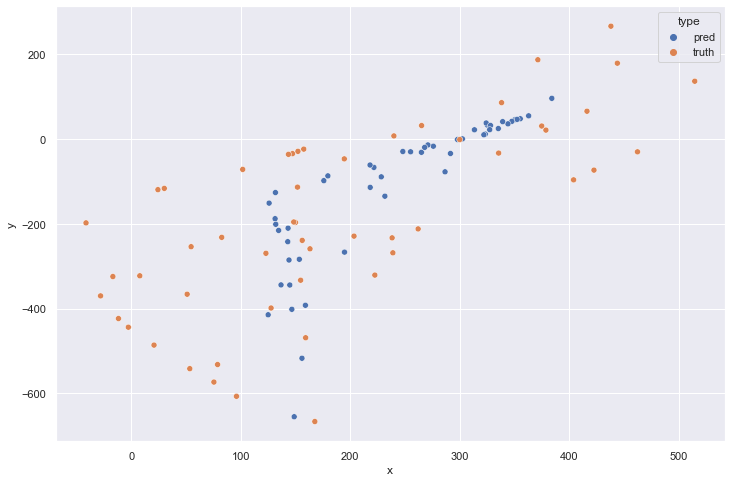

In [77]:
def analyze_predictions(y_test, x_test=None, file=None, model=None):
    if x_test is not None:
        preds = model.predict(x_test)
        preds = pd.DataFrame(preds, columns=["x", "y", "z"])
    else:
        preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    sns.set()
    plt.figure(figsize=(12, 8))
    concat = concat[concat["x"]<1000]
    sns.scatterplot(x="x", y="y", data=concat, hue="type")
    return concat

concat = analyze_predictions(y_test_ae, file="cnn_ae_preds_macbook.csv")

,x,y,z,type
0,139.506378,-464.446259,646.172180,pred
1,190.579102,-134.527542,504.605316,pred
2,53.099098,-195.456131,504.183716,pred
3,104.708855,-318.067871,544.378479,pred
4,53.477165,-363.128540,508.330261,pred
...,...,...,...,...
201,101.856625,-71.843598,505.959900,truth
202,9.788215,-466.265013,508.363600,truth
203,-18.351124,-153.439770,503.148400,truth
204,-27.858675,-370.149786,513.494100,truth


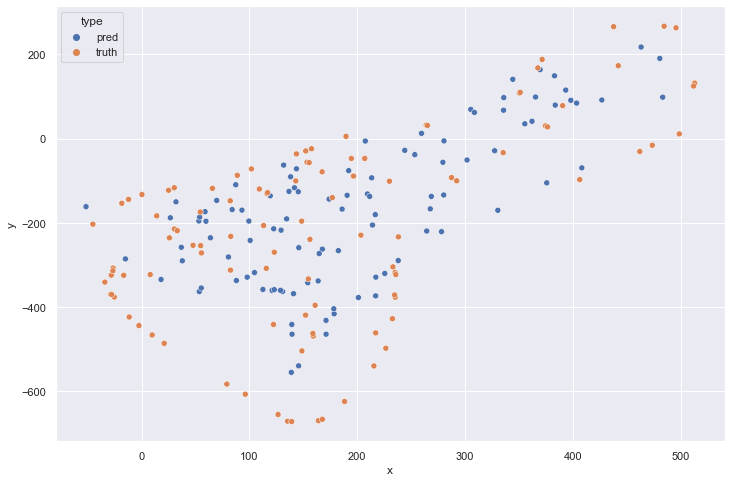

In [78]:
analyze_predictions(test_y, x_test=test_x, model=model_ae)

,x,y,z,type
0,126.097694,-110.654920,493.97960,pred
1,342.627560,20.538002,521.77826,pred
2,92.578390,-204.848510,484.60250,pred
3,99.297780,-506.371900,535.76000,pred
4,287.976470,-93.556430,521.15186,pred
...,...,...,...,...
99,371.132087,186.804475,509.34540,truth
100,378.491911,20.895751,501.85620,truth
101,127.716994,-398.749010,514.13950,truth
102,24.488283,-119.570240,507.88460,truth


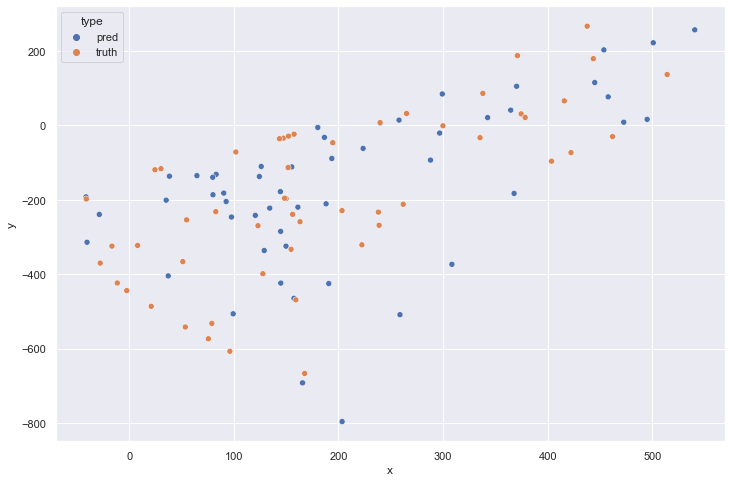

In [80]:
analyze_predictions(y_test_ae_cnn, file="cnn_ae_al_preds.csv")